# Day 5-02｜成果圖表建立
> Python 籃球運動資料分析課程  
> 將角度資料、球軌跡與骨架示意整理成可展示的圖片。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 把分析表格轉成報告圖表。
- 建立角度折線圖與球軌跡圖。
- 輸出一張代表性的骨架示意圖。

## 完成產出
- 可放入成果展示的 PNG 圖片。

## 課堂要求
- 按照本單元順序執行各段程式。
- 僅修改題目指定的變數、路徑或參數。
- 完成指定輸出後，記錄結果並供課堂討論。


## 執行階段提醒
請優先使用 **GPU** 或 **TPU** 的執行階段；不要使用純 CPU 執行。  
YOLO、MediaPipe 與影片處理在純 CPU 上會明顯較慢，容易讓課堂操作卡住。


## 課程流程
1. 載入 Day 4 產生的姿態與球軌跡資料。
2. 產生角度與軌跡圖。
3. 儲存展示圖片。


In [1]:
from pathlib import Path
import sys

bootstrap_candidates = [
    Path.cwd().resolve(),
    *Path.cwd().resolve().parents,
    Path("/content/basketball_hackathon/course"),
    Path("/content/basketball_hackathon_course"),
    Path("/content/drive/MyDrive/basketball_hackathon/course"),
]
for candidate in bootstrap_candidates:
    if (candidate / "src" / "course_setup.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "找不到 src/course_setup.py。請先執行 init_colab.ipynb，確認課程已同步到 /content/basketball_hackathon/course 或目前 repo 內。"
    )

from src.course_setup import DEFAULT_COURSE_ROOT, bootstrap_course_notebook  # noqa: E402

COURSE_ROOT = bootstrap_course_notebook(DEFAULT_COURSE_ROOT, mount_drive=True)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [2]:
import pandas as pd
from src.shooting_utils import draw_skeleton
from src.plot_utils import plot_angle_series, plot_ball_path
from src.cv_utils import save_image_rgb, show_image

RESULTS = COURSE_ROOT / "assets" / "results"
pose_csv = RESULTS / "d4_02_pose_angles.csv"
ball_csv = RESULTS / "d4_03_ball_track.csv"

if not pose_csv.exists():
    raise FileNotFoundError(f"找不到姿態結果：{pose_csv}。請先完成 Day 4-02。")
if not ball_csv.exists():
    raise FileNotFoundError(f"找不到球軌跡結果：{ball_csv}。請先完成 Day 4-03。")

pose_df = pd.read_csv(pose_csv)
ball_df = pd.read_csv(ball_csv)

if pose_df.empty:
    raise RuntimeError("d4_02_pose_angles.csv 是空的，請重新執行 Day 4-02。")
if ball_df.empty:
    raise RuntimeError("d4_03_ball_track.csv 是空的，請重新執行 Day 4-03。")


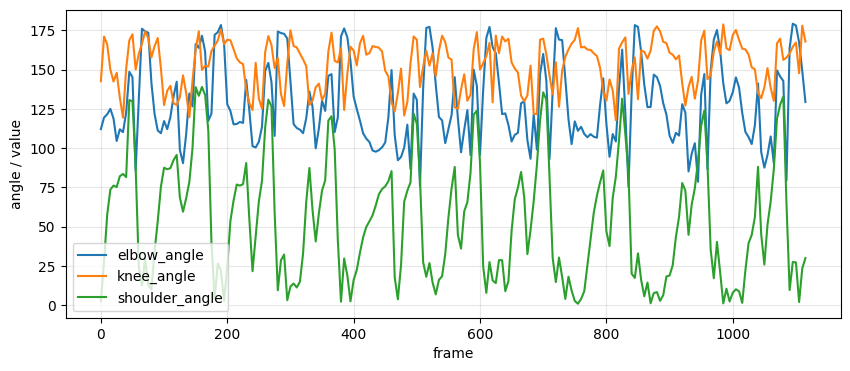

saved: H:\Repos\basketball-hackathon-course\assets\results\d5_02_pose_angles.png


In [3]:
angle_png = RESULTS / "d5_02_pose_angles.png"
plot_angle_series(
    pose_df, ["elbow_angle", "knee_angle", "shoulder_angle"], output_path=angle_png
)
print("saved:", angle_png)

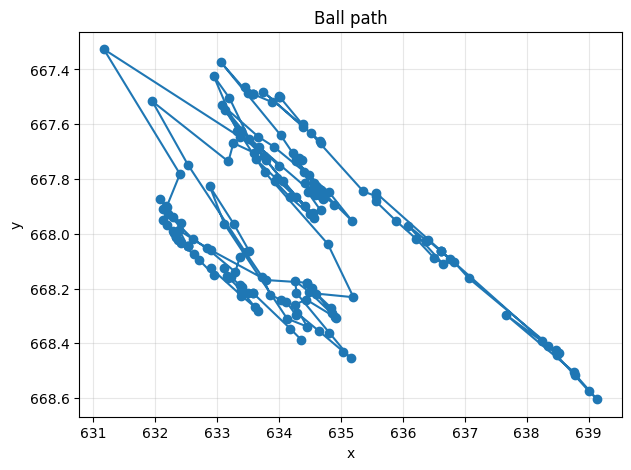

saved: H:\Repos\basketball-hackathon-course\assets\results\d5_02_ball_path.png


In [4]:
ball_png = RESULTS / "d5_02_ball_path.png"
plot_ball_path(ball_df, output_path=ball_png)
print("saved:", ball_png)


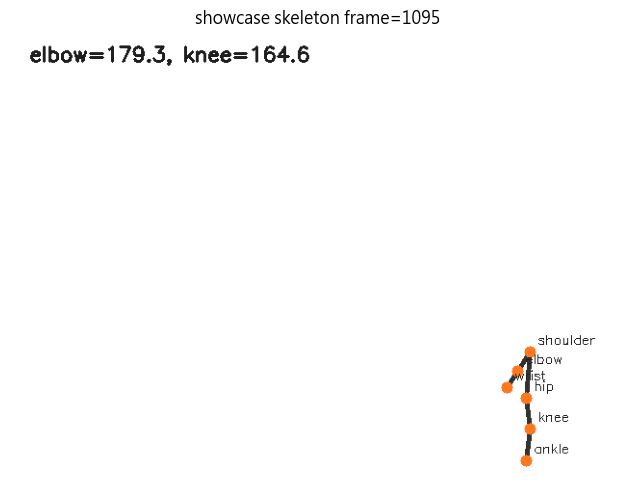

saved: H:\Repos\basketball-hackathon-course\assets\results\d5_02_showcase_skeleton.png


In [5]:
# 選一個 elbow angle 最大的 frame 當展示骨架。
idx = int(pose_df["elbow_angle"].idxmax())
row = pose_df.iloc[idx]
skeleton = draw_skeleton(640, 480, row)
show_image(skeleton, f"showcase skeleton frame={int(row.frame)}")
skeleton_png = RESULTS / "d5_02_showcase_skeleton.png"
save_image_rgb(skeleton_png, skeleton)
print("saved:", skeleton_png)


## 本單元產出檔案

- `assets/results/d5_02_pose_angles.png`：角度圖表。
- `assets/results/d5_02_ball_path.png`：球軌跡圖表。
- `assets/results/d5_02_showcase_skeleton.png`：展示用骨架圖。
